# 02 — Feature Engineering and Activation-Style Labels

**Purpose.** Convert the cleaned Complete Journey transactions (notebook 01) into weekly customer journey sequences, and assign activation-style labels using **future-window weak supervision**. The output is the model-ready dataset used by notebooks 03 and 04.

**Leakage control.** An earlier prototype computed labels from the same in-window signals fed to the models, which lets a model re-learn the labeling rules instead of learning predictive behavior. Here, every label is decided by what a household does in the **4 weeks after** an input sequence; model inputs stay strictly in the past.

**Inputs:** `data/processed/transactions_clean.parquet`  
**Outputs:** `sequences_x.npy`, `labels_y.npy`, `sample_index.parquet` in `data/processed/`

## 1. Setup

In [1]:
# Make the src/ package importable when running from the notebooks/ folder.
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.append(str(REPO_ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
RANDOM_STATE = 7
np.random.seed(RANDOM_STATE)

## 2. Load Cleaned Transactions

The cleaned table from notebook 01 already excludes duplicates and the *coupon/misc items* and *fuel* categories. The schema is asserted so a wrong input fails loudly.

In [2]:
from campaign_strategist.config import PROCESSED_DATA_DIR

transactions = pd.read_parquet(PROCESSED_DATA_DIR / 'transactions_clean.parquet')

expected = {'household_id','week','product_category','quantity','sales_value','discount_value','used_coupon'}
assert expected.issubset(transactions.columns), f'Missing columns: {expected - set(transactions.columns)}'
assert not transactions['product_category'].isin(['coupon/misc items','fuel']).any(), 'Run notebook 01 first (outlier categories present).'

print(f'{len(transactions):,} rows | {transactions.household_id.nunique():,} households | '
      f'weeks {transactions.week.min()}-{transactions.week.max()}')

73,451 rows | 2,376 households | weeks 1-53


## 3. Weekly Journey Sequences

Each household-week becomes one time step with 15 features: an activity flag; log-scaled spend, quantity, and trip count (log scaling reduces the right skew observed in notebook 01, Section 5.3); a discount rate; a coupon indicator; and the household's spend share across the top 8 product categories plus *other*.

Sliding windows of **12 weeks** form one sample, and the **4 weeks** after each window form the future horizon used only for labeling. Windows with fewer than 2 active weeks are skipped: such households show too little behavior to be part of a targeted marketing audience.

Two design choices worth noting for the report:

- Feature scaling is **not** applied here. The scaler must be fit on the training split only (notebook 03), otherwise test information leaks into preprocessing.
- The 12-week window balances history depth against sample coverage; households need at least 16 consecutive observable weeks (12 + 4) to produce a sample.

In [3]:
from campaign_strategist.features import build_sequence_dataset

SEQUENCE_LENGTH = 12
PREDICTION_HORIZON = 4

dataset = build_sequence_dataset(
    transactions,
    sequence_length=SEQUENCE_LENGTH,
    prediction_horizon=PREDICTION_HORIZON,
    top_n_categories=8,
    min_window_active_weeks=2,
)

print('Sequence tensor :', dataset.x.shape, '(samples, weeks, features)')
print('Labels          :', dataset.y.shape)
print('Abstained       :', f'{dataset.n_abstained:,} samples (no clear future signal)')
print('Households      :', dataset.sample_index.household_id.nunique())
print('Features        :', dataset.feature_names)

Sequence tensor : (38028, 12, 15) (samples, weeks, features)
Labels          : (38028,)
Abstained       : 22,508 samples (no clear future signal)
Households      : 2044
Features        : ['is_active', 'log_sales', 'log_quantity', 'log_trips', 'discount_rate', 'coupon_rate', 'share_soft drinks', 'share_beef', 'share_fluid milk products', 'share_cheese', 'share_frzn meat/meat dinners', 'share_beers/ales', 'share_bag snacks', 'share_frozen pizza', 'share_other']


## 4. Label Design: Future-Window Weak Supervision

The six activation styles are assigned by rules that read only the future horizon (plus household tenure, a customer property rather than a window behavior). The rules are applied in priority order; a sample takes the first rule that fires. Samples with no clear signal **abstain** and are excluded from training, which is standard weak-supervision practice (Ratner et al., 2017).

| Priority | Label | Rule (draft thresholds) |
| --- | --- | --- |
| 1 | New customer onboarding | household tenure ≤ 8 weeks at the end of the window |
| 2 | Win-back reminder | ≥ 3 active weeks in window AND 0 active weeks in future |
| 3 | Price-led coupon | coupon redeemed in future, OR mean future discount rate ≥ 0.15 |
| 4 | Seasonal spotlight | future overlaps weeks 46–53 AND future weekly spend > 1.2× window norm |
| 5 | Cross-sell bundle | future purchase in a category not bought in the window |
| 6 | Loyalty reward | ≥ 2 active future weeks at/above the household's usual spend |
| — | *(abstain)* | none of the above |

The thresholds live in `src/campaign_strategist/labels.py` (`DEFAULT_LABEL_CONFIG`) so they can be tuned in one place. One empirical note: only about 3% of active weeks in this dataset redeem a coupon, so the price-led rule relies mostly on the retail discount rate — price sensitivity in this data expresses itself through shelf discounts more than coupon redemptions.

## 5. Label Distribution

The class balance check below matters because an earlier prototype produced 67% of samples in a single class, which makes accuracy misleading and training unstable.

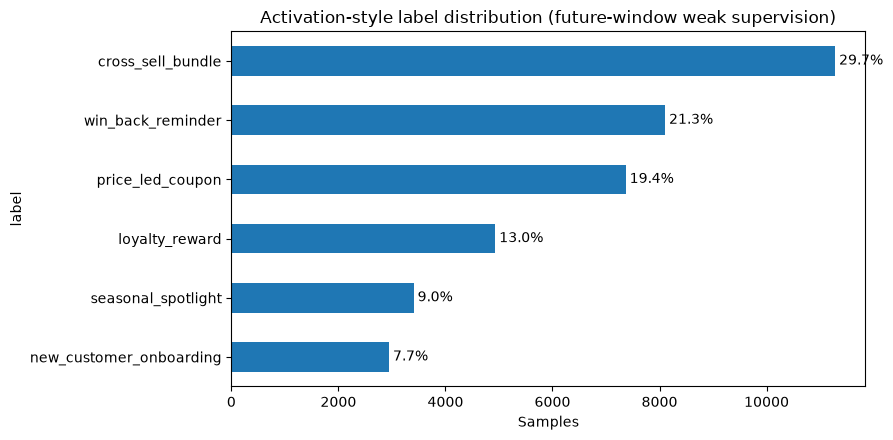

,count,%
label,,
cross_sell_bundle,11279,29.7
win_back_reminder,8102,21.3
price_led_coupon,7367,19.4
loyalty_reward,4930,13.0
seasonal_spotlight,3405,9.0
new_customer_onboarding,2945,7.7


In [4]:
label_counts = dataset.sample_index['label'].value_counts()
label_share = (label_counts / len(dataset.sample_index) * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 4.5))
label_counts.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Activation-style label distribution (future-window weak supervision)')
ax.set_xlabel('Samples')
for i, (name, n) in enumerate(label_counts.sort_values().items()):
    ax.text(n, i, f' {label_share[name]}%', va='center')
plt.tight_layout()
plt.show()

pd.concat([label_counts, label_share.rename('%')], axis=1)

*Discussion.* No class exceeds ~30% and the smallest class holds several thousand samples, so all six activation styles are learnable. The imbalance that remains (cross-sell ≈ 4× onboarding) is handled with class weights during training in notebook 03. Macro-F1, not accuracy, will be the headline metric.

## 6. Sanity Check: Example Journeys

To verify the labels match marketing intuition, one sampled household journey is shown for two contrasting labels: a win-back case (active history, silent future) and a loyalty case (steady activity at or above the household norm).

In [5]:
def show_example(label_name):
    row = dataset.sample_index[dataset.sample_index.label == label_name].iloc[0]
    pos = dataset.sample_index.index.get_loc(row.name)
    active_flags = dataset.x[pos, :, dataset.feature_names.index('is_active')].astype(int)
    print(f'{label_name:26s} household {row.household_id} | window ends week {row.end_week} | '
          f'active weeks pattern: {"".join(map(str, active_flags))}')

for name in ['win_back_reminder', 'loyalty_reward', 'new_customer_onboarding']:
    show_example(name)

win_back_reminder          household 1 | window ends week 38 | active weeks pattern: 100100110001
loyalty_reward             household 1 | window ends week 20 | active weeks pattern: 101101000101
new_customer_onboarding    household 100 | window ends week 12 | active weeks pattern: 000000010010


## 7. Save Model-Ready Outputs

In [6]:
np.save(PROCESSED_DATA_DIR / 'sequences_x.npy', dataset.x)
np.save(PROCESSED_DATA_DIR / 'labels_y.npy', dataset.y)
dataset.sample_index.to_parquet(PROCESSED_DATA_DIR / 'sample_index.parquet', index=False)

with open(PROCESSED_DATA_DIR / 'feature_names.txt', 'w') as f:
    f.write('\n'.join(dataset.feature_names))

print('Saved:', sorted(p.name for p in PROCESSED_DATA_DIR.iterdir()))

Saved: ['feature_names.txt', 'labels_y.npy', 'sample_index.parquet', 'sequences_x.npy', 'transactions_clean.parquet']


## 8. Summary

The cleaned transactions were converted into 12-week journey sequences with 15 behavioral features per week, and each sequence was labeled with one of six activation styles using rules that read only the four weeks following the sequence. This future-window design removes the label leakage present in the earlier prototype: a model can now only score well by finding past behavior patterns that genuinely predict future marketing-relevant behavior. The resulting dataset (≈38,000 labeled samples across 2,300+ households, with all classes between roughly 8% and 30%) is saved for baseline and LSTM training in notebook 03.

## References

84.51°. (n.d.). *The Complete Journey* [Data set]. https://www.8451.com/area51

Harris, C. R., et al. (2020). Array programming with NumPy. *Nature, 585*, 357–362.

McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56–61.

Ratner, A., Bach, S. H., Ehrenberg, H., Fries, J., Wu, S., & Ré, C. (2017). Snorkel: Rapid training data creation with weak supervision. *Proceedings of the VLDB Endowment, 11*(3), 269–282.